# Tuning NES with Optuna: accuracy vs cost, and what matters

This tutorial finds good hyperparameters of **NES-OP / NES-TP for your velocity model** with a two-objective search,
then shows which hyperparameters drive the result.

| | |
|---|---|
| **Objective 1: loss** | mean $\lvert H_2\rvert$ (eqs. 13–14 of [Grubas et al., 2023](https://doi.org/10.1016/j.jcp.2022.111789)) on a fixed validation set. The loss is non-dimensional and tracks RMAE w.r.t. the 2nd-order factored FMM almost independently of the model (paper, Fig. 10), so it is a reference-free proxy of accuracy. |
| **Objective 2: FLOPs** | FLOPs of one forward evaluation × collocation points × epochs: a deterministic proxy of training time, the same on every backend and machine. |
| **Sampler** | multi-objective TPE (MOTPE, [Ozaki et al., 2022](https://doi.org/10.1613/jair.1.13188)), Optuna's default for multi-objective studies since v5.0. |
| **Pruning** | median stopping rule ([Golovin et al., 2017](https://doi.org/10.1145/3097983.3098043), sec. 3.2.2) on the validation-loss learning curve. Optuna has no `trial.report` for multi-objective studies, so `NES.hpo` applies the rule in a Keras callback. A trial is compared with completed trials of lower or equal FLOPs: it can reach the Pareto front only by beating the cheaper ones. |
| **Importance** | PED-ANOVA ([Watanabe et al., 2023](https://arxiv.org/abs/2304.10255)), Optuna's default since v5.0: importance for reaching the Pareto front, and for the loss alone. |

The result is a **Pareto front**: every point is a setting that no other tried setting beats on both accuracy and cost.
You pick the trade-off that fits your application and train it longer.

The budgets below are small so that the notebook runs in minutes on a CPU. For real use, raise `n_trials` (100–300) and `epochs`.

In [1]:
# !pip install "git+https://github.com/sgrubas/NES.git@keras3" "optuna>=5" matplotlib eikonalfm
import os
os.environ.setdefault("KERAS_BACKEND", "jax")   # or "tensorflow", "torch"

import time
import numpy as np
import matplotlib.pyplot as plt
import keras, optuna
import NES
import NES.hpo as hpo
from NES.velocity import LuneburgLens

print("NES", NES.__version__, "| Keras", keras.__version__, keras.backend.backend(), "| Optuna", optuna.__version__)

NES 0.3.0 | Keras 3.15.1 jax | Optuna 5.0.0


## 1. Velocity model and reference

We use the **Luneburg lens**: a local low-velocity lens ($v = v_\text{out}/\sqrt{2 - r^2/R^2}$ inside, $v_\text{out}$ outside)
whose traveltimes between points inside the lens have a closed form. That gives an exact RMAE for every trial, so we can check how well the loss works as a proxy.

**For your own model**, replace `velocity` by any `NES.velocity.BaseVelocity` (e.g. `NES.velocity.Interpolator(V, x, z)`) and build the
reference with `hpo.fmm_reference` (2nd-order factored FMM, as in the paper). The reference is optional: the search itself uses only the loss.

In [2]:
velocity = LuneburgLens(v_out=2.0, R=1.0, xmin=[-1.2, -1.2], xmax=[1.2, 1.2])
xs = np.array([0.4, -0.3])                       # source of NES-OP

# exact reference on receivers inside the lens
grid = NES.RegularGrid(velocity)((121, 121)).reshape(-1, 2)
grid = grid[velocity.inside(grid) & (np.abs(grid - xs).sum(-1) > 1e-2)]
reference = (grid, velocity.time(grid, xs))

# the same check against the 2nd-order factored FMM (what you would use for an arbitrary model)
try:
    x_fmm, t_fmm = hpo.fmm_reference(velocity, [xs], (241, 241))
    x_r, t_r = x_fmm[0, ..., 2:], t_fmm[0]
    t_exact = velocity.time(x_r, x_fmm[0, 0, 0, :2])
    ok = np.isfinite(t_exact) & (t_exact > 0)
    print(f"FMM vs closed form inside the lens: RMAE = {100 * np.abs(t_r - t_exact)[ok].sum() / t_exact[ok].sum():.4f} %")
except ImportError:
    print("eikonalfm is not installed: skipping the FMM check")

FMM vs closed form inside the lens: RMAE = 0.0003 %


## 2. Search: NES-OP

`hpo.search_space()` defines the space: a `(low, high)` tuple is a range, a list is categorical, a single value is fixed.
The Hamiltonian power $p$ and the L1 loss are fixed on purpose: they change the scale of the loss, which would make the first objective incomparable across trials.

Every trial trains for `epochs`; every `eval_every` epochs the validation loss is recorded and the stopping rule decides whether to continue.
Diverged trials (NaN loss) are stopped at once.

In [3]:
space = hpo.search_space(nl=(2, 6), nu=(16, 96), n_train=(1000, 12000))
rule = hpo.MedianStoppingRule(n_startup_trials=5, n_warmup_steps=3, reference="cheaper")

t0 = time.time()
study_op = hpo.tune(velocity, solver="OP", xs=xs, n_trials=30, epochs=150, eval_every=10,
                    search_space=space, pruning=rule, reference=reference, seed=0, verbose=False)
states = [t.state.name for t in study_op.trials]
print(f"{len(states)} trials in {time.time() - t0:.0f} s:", {s: states.count(s) for s in set(states)})

30 trials in 306 s: {'COMPLETE': 27, 'PRUNED': 3}


### Pareto front

Grey points are all completed trials, blue ones are Pareto-optimal. Moving right buys accuracy with compute; the knee of the front is usually the best value.

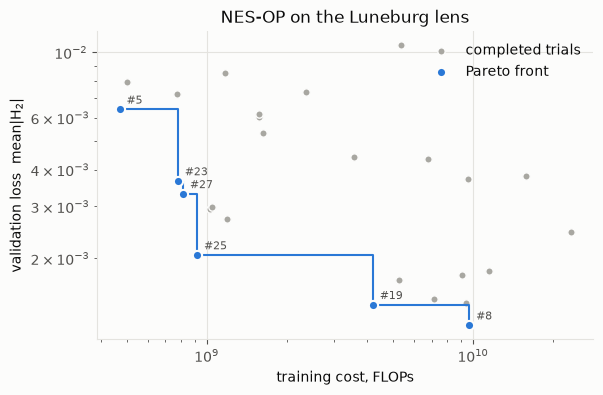

trial      loss     FLOPs  RMAE % params  hyperparameters
    5  6.41e-03  4.71e+08   0.262    810  {'nl': 2, 'nu': 26, 'act': 'ad-sin-1', 'improved_mlp': False, 'lr': 0.00796, 'decay': 0.0005, 'n_train': 1933, 'n_batches': 8}
   23  3.66e-03  7.79e+08   0.136   1402  {'nl': 3, 'nu': 25, 'act': 'gauss', 'improved_mlp': False, 'lr': 0.00888, 'decay': 0.00037, 'n_train': 1848, 'n_batches': 8}
   27  3.31e-03  8.15e+08   0.060   2540  {'nl': 4, 'nu': 27, 'act': 'gauss', 'improved_mlp': True, 'lr': 0.00345, 'decay': 0.00125, 'n_train': 1004, 'n_batches': 8}
   25  2.05e-03  9.20e+08   0.036   2852  {'nl': 5, 'nu': 25, 'act': 'gauss', 'improved_mlp': True, 'lr': 0.00657, 'decay': 0.00034, 'n_train': 1004, 'n_batches': 8}
   19  1.39e-03  4.21e+09   0.049   3537  {'nl': 5, 'nu': 28, 'act': 'ad-gauss-1', 'improved_mlp': True, 'lr': 0.00639, 'decay': 0.00033, 'n_train': 3732, 'n_batches': 8}
    8  1.19e-03  9.68e+09   0.025   6639  {'nl': 5, 'nu': 39, 'act': 'ad-gauss-1', 'improved_mlp': True

In [4]:
SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#a8a7a1"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
                     "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10, "legend.frameon": False})

def completed(study):
    return [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

def plot_front(study, title):
    front = hpo.pareto_front(study)
    done = completed(study)
    fig, ax = plt.subplots(figsize=(6.4, 4))
    ax.scatter([t.values[1] for t in done], [t.values[0] for t in done], s=28, color=GREY,
               edgecolor=SURFACE, linewidth=1, label="completed trials", zorder=2)
    ax.step([r["flops"] for r in front], [r["loss"] for r in front], where="post", color=BLUE, lw=1.5, zorder=3)
    ax.scatter([r["flops"] for r in front], [r["loss"] for r in front], s=44, color=BLUE,
               edgecolor=SURFACE, linewidth=1.5, label="Pareto front", zorder=4)
    for r in front:
        ax.annotate(f"#{r['number']}", (r["flops"], r["loss"]), textcoords="offset points", xytext=(5, 4),
                    fontsize=8, color=MUTED)
    ax.set(xscale="log", yscale="log", xlabel="training cost, FLOPs", ylabel="validation loss  mean|H$_2$|", title=title)
    ax.legend(loc="upper right")
    plt.show()
    return front

front_op = plot_front(study_op, "NES-OP on the Luneburg lens")
print(f"{'trial':>5} {'loss':>9} {'FLOPs':>9} {'RMAE %':>7} {'params':>6}  hyperparameters")
for r in front_op:
    p = {k: (round(v, 5) if isinstance(v, float) else v) for k, v in r["params"].items()}
    print(f"{r['number']:>5} {r['loss']:9.2e} {r['flops']:9.2e} {100 * r['rmae']:7.3f} {r['n_params']:>6}  {p}")

### Is the loss a good proxy of RMAE?

Each completed trial's final loss against its exact RMAE. The dashed line is the empirical relation NES uses for early stopping
(`NES_EarlyStopping`: RMAE ≈ 10<sup>−0.16</sup> · loss, the trend of the paper's Fig. 10). That trend was fit to the maximum error over
five runs, so it is an upper-bound estimate and points below it are expected. What the search needs is a monotone relation:
ranking trials by loss should rank them by accuracy, which the Spearman rank correlation in the title measures.

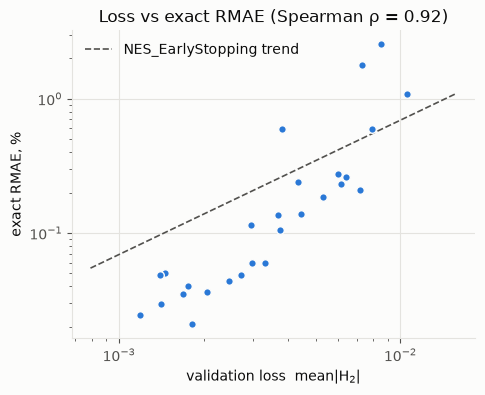

In [5]:
from scipy.stats import spearmanr

done = completed(study_op)
loss = np.array([t.values[0] for t in done])
rmae = np.array([t.user_attrs["rmae"] for t in done])
rho = spearmanr(loss, rmae).correlation

fig, ax = plt.subplots(figsize=(5.2, 4))
ax.scatter(loss, 100 * rmae, s=30, color=BLUE, edgecolor=SURFACE, linewidth=1, zorder=3)
xl = np.geomspace(loss.min() / 1.5, loss.max() * 1.5, 50)
ax.plot(xl, 100 * hpo.loss_to_rmae(xl), ls="--", color=MUTED, lw=1.2, label="NES_EarlyStopping trend")
ax.set(xscale="log", yscale="log", xlabel="validation loss  mean|H$_2$|", ylabel="exact RMAE, %",
       title=f"Loss vs exact RMAE (Spearman ρ = {rho:.2f})")
ax.legend(loc="upper left")
plt.show()

### What pruning did

Validation-loss curves of all trials: completed in grey, pruned in orange (each stops where the rule fired).
Pruned trials cost only the epochs they ran, and MOTPE still uses them as examples of bad settings.

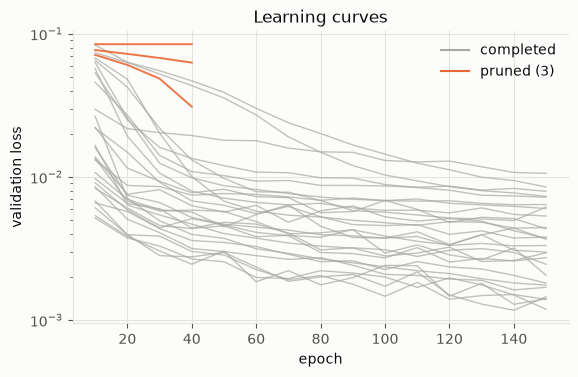

epochs run: 4170 of 4500 (93 %)


In [6]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
n_pruned = 0
for t in study_op.trials:
    curve = t.user_attrs.get("curve")
    if not curve:
        continue
    pruned = t.state == optuna.trial.TrialState.PRUNED
    n_pruned += pruned
    epochs = 10 * np.arange(1, len(curve) + 1)
    ax.plot(epochs, curve, color=ORANGE if pruned else GREY, lw=1.4 if pruned else 1, alpha=0.9 if pruned else 0.7,
            zorder=3 if pruned else 2)
ax.plot([], [], color=GREY, label="completed"); ax.plot([], [], color=ORANGE, label=f"pruned ({n_pruned})")
ax.set(yscale="log", xlabel="epoch", ylabel="validation loss", title="Learning curves")
ax.legend(loc="upper right")
plt.show()

spent = sum(len(t.user_attrs.get("curve", [])) for t in study_op.trials) * 10
print(f"epochs run: {spent} of {len(study_op.trials) * 150} ({100 * spent / (len(study_op.trials) * 150):.0f} %)")

## 3. Hyperparameter importance

PED-ANOVA answers *which hyperparameters decide whether a trial is among the best*: `pareto` ranks them for reaching the Pareto front,
`loss` for accuracy alone. FLOPs are left out because they are a known function of `nl`, `nu`, `n_train`, `improved_mlp` and `reciprocity`.
With a few dozen trials, read the ranking, not the decimals.

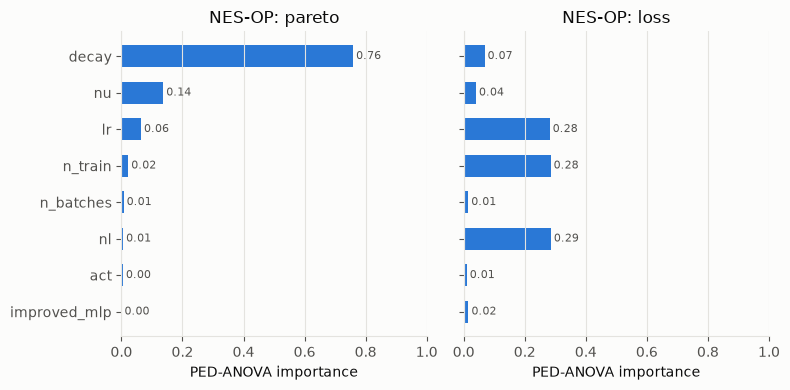

In [7]:
def plot_importance(study, title):
    imp = hpo.param_importances(study)
    names = sorted(imp["pareto"], key=lambda k: imp["pareto"][k])
    fig, axes = plt.subplots(1, 2, figsize=(8, 0.35 * len(names) + 1.2), sharey=True)
    for ax, key in zip(axes, ["pareto", "loss"]):
        vals = [imp[key].get(n, 0.0) for n in names]
        ax.barh(names, vals, color=BLUE, height=0.6)
        for y, v in enumerate(vals):
            ax.text(v + 0.01, y, f"{v:.2f}", va="center", fontsize=8, color=MUTED)
        ax.set(xlim=(0, 1), xlabel="PED-ANOVA importance", title=f"{title}: {key}")
        ax.grid(axis="y", visible=False)
    plt.tight_layout()
    plt.show()
    return imp

imp_op = plot_importance(study_op, "NES-OP")

## 4. Pick a trade-off and train it

A simple rule: the cheapest Pareto trial whose loss is within 1.5× of the best loss. Then train it longer (more epochs is the one knob
the search held fixed) and check the exact error.

In [8]:
best = min(r["loss"] for r in front_op)
choice = min((r for r in front_op if r["loss"] <= 1.5 * best), key=lambda r: r["flops"])
print("chosen trial", choice["number"], choice["params"])

keras.utils.set_random_seed(0)
nes, train_kw = hpo.build(velocity, choice["params"], solver="OP", xs=xs, search_space=space)
t0 = time.time()
nes.train(**train_kw, epochs=600, verbose=0)
x_ref, t_ref = reference
print(f"trained in {time.time() - t0:.0f} s, exact RMAE = {100 * np.abs(nes.Traveltime(x_ref) - t_ref).sum() / t_ref.sum():.3f} %")

chosen trial 19 {'nl': 5, 'nu': 28, 'act': 'ad-gauss-1', 'improved_mlp': True, 'lr': 0.006392865511990966, 'decay': 0.0003331691255333768, 'n_train': 3732, 'n_batches': 8}


trained in 14 s, exact RMAE = 0.010 %


## 5. The same for NES-TP

For the two-point solver the search also chooses the reciprocity mode (`output`, `first_layer`, `invariant`).
The reference here is a set of source-receiver pairs inside the lens.

16 trials in 594 s: {'COMPLETE': 15, 'PRUNED': 1}


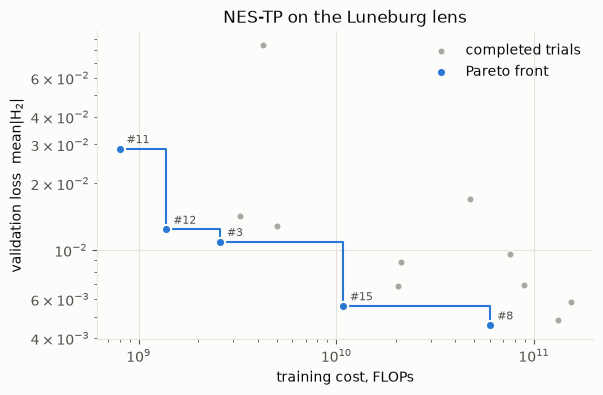

# 11  loss 2.87e-02  FLOPs 8.00e+08  RMAE 1.640 %  reciprocity=output  nl=2  nu=16
# 12  loss 1.24e-02  FLOPs 1.38e+09  RMAE 0.448 %  reciprocity=first_layer  nl=4  nu=19
#  3  loss 1.09e-02  FLOPs 2.58e+09  RMAE 0.540 %  reciprocity=output  nl=3  nu=21
# 15  loss 5.60e-03  FLOPs 1.08e+10  RMAE 0.142 %  reciprocity=first_layer  nl=6  nu=38
#  8  loss 4.58e-03  FLOPs 6.02e+10  RMAE 0.114 %  reciprocity=first_layer  nl=6  nu=56


In [9]:
rng = np.random.default_rng(1)
r, a = np.sqrt(rng.uniform(0, 1, (2, 6000))), rng.uniform(0, 2 * np.pi, (2, 6000))
pairs = np.concatenate([np.stack([r[0] * np.cos(a[0]), r[0] * np.sin(a[0])], -1),
                        np.stack([r[1] * np.cos(a[1]), r[1] * np.sin(a[1])], -1)], -1)
pairs = pairs[np.abs(pairs[:, 2:] - pairs[:, :2]).sum(-1) > 1e-2]
reference_tp = (pairs, velocity.time(pairs[:, 2:], pairs[:, :2]))

space_tp = hpo.search_space(nl=(2, 6), nu=(16, 96), n_train=(5000, 40000))
t0 = time.time()
study_tp = hpo.tune(velocity, solver="TP", n_trials=16, epochs=100, eval_every=10, search_space=space_tp,
                    pruning=hpo.MedianStoppingRule(n_startup_trials=4, n_warmup_steps=3), reference=reference_tp,
                    seed=0, verbose=False)
states = [t.state.name for t in study_tp.trials]
print(f"{len(states)} trials in {time.time() - t0:.0f} s:", {s: states.count(s) for s in set(states)})
front_tp = plot_front(study_tp, "NES-TP on the Luneburg lens")
for r in front_tp:
    print(f"#{r['number']:>3}  loss {r['loss']:.2e}  FLOPs {r['flops']:.2e}  RMAE {100 * r['rmae']:.3f} %  "
          f"reciprocity={r['params']['reciprocity']}  nl={r['params']['nl']}  nu={r['params']['nu']}")

## Notes

* **Persist and resume**: pass `storage="sqlite:///nes_hpo.db", study_name="lens", load_if_exists=True` to `hpo.tune` to keep the study on disk and continue it later (`study=` also continues an in-memory study).
* **Interactive plots**: `optuna.visualization.plot_pareto_front(study_op, target_names=["loss", "FLOPs"])` and `optuna.visualization.plot_param_importances(study_op)` give Plotly versions of the figures above.
* **Pruning budget**: the median stopping rule needs `n_startup_trials` comparable completed trials before it prunes anything, so the first trials always run to the end. With the cost-aware reference set, small studies prune little (here 3 of 30 trials, 93 % of the epochs ran); the savings grow with the number of trials. `reference="all"` prunes more but can stop cheap trials that belong to the low-cost end of the front.
* **FLOPs ignore per-step overhead**: the cost is the same for 1 or 8 batches per epoch, while 8 batches give 8× more optimizer steps. The search exploits this (the NES-OP front above uses 8 batches throughout). On a GPU, where small batches underuse the device, cap it, e.g. `hpo.search_space(n_batches=[1, 2, 4])`.
* **Custom spaces**: fix a value to exclude it from the search, e.g. `hpo.search_space(act="ad-gauss-1", improved_mlp=False)`.

**References**
Golovin D. et al. (2017) Google Vizier: a service for black-box optimization. *KDD 2017*. doi:10.1145/3097983.3098043 ·
Ozaki Y. et al. (2022) Multiobjective tree-structured Parzen estimator. *JAIR* 73, 1209–1250. doi:10.1613/jair.1.13188 ·
Watanabe S., Bansal A., Hutter F. (2023) PED-ANOVA: efficiently quantifying hyperparameter importance in arbitrary subspaces. *IJCAI*. arXiv:2304.10255 ·
Grubas S., Duchkov A., Loginov G. (2023) Neural Eikonal solver. *JCP* 474, 111789. doi:10.1016/j.jcp.2022.111789